In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [3]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=128)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 256)
        self.fc3 = nn.Linear(256, 28*28)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = x.view(-1, 28*28)
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        x_hat = torch.sigmoid(self.fc3(torch.relu(self.fc2(z))))
        return x_hat, mu, logvar


In [5]:
def vae_loss(x_hat, x, mu, logvar, use_kl=True):
    recon_loss = nn.functional.binary_cross_entropy(
        x_hat, x.view(-1, 28*28), reduction='sum'
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    if use_kl:
        total_loss = recon_loss + kl_loss
    else:
        total_loss = recon_loss

    return total_loss


In [6]:
vae_kl = VAE(latent_dim=2)
optimizer = optim.Adam(vae_kl.parameters(), lr=1e-3)

for epoch in range(10):
    total_loss = 0
    for x, _ in train_loader:
        x_hat, mu, logvar = vae_kl(x)
        loss = vae_loss(x_hat, x, mu, logvar, use_kl=True)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"VAE WITH KL | Epoch {epoch+1} | Loss: {total_loss:.0f}")


VAE WITH KL | Epoch 1 | Loss: 11696043
VAE WITH KL | Epoch 2 | Loss: 10189455
VAE WITH KL | Epoch 3 | Loss: 9908489
VAE WITH KL | Epoch 4 | Loss: 9769272
VAE WITH KL | Epoch 5 | Loss: 9677130
VAE WITH KL | Epoch 6 | Loss: 9604681
VAE WITH KL | Epoch 7 | Loss: 9543710
VAE WITH KL | Epoch 8 | Loss: 9489371
VAE WITH KL | Epoch 9 | Loss: 9443075
VAE WITH KL | Epoch 10 | Loss: 9397250


In [7]:
vae_no_kl = VAE(latent_dim=2)
optimizer = optim.Adam(vae_no_kl.parameters(), lr=1e-3)

for epoch in range(10):
    total_loss = 0
    for x, _ in train_loader:
        x_hat, mu, logvar = vae_no_kl(x)
        loss = vae_loss(x_hat, x, mu, logvar, use_kl=False)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"VAE NO KL | Epoch {epoch+1} | Loss: {total_loss:.0f}")


VAE NO KL | Epoch 1 | Loss: 11222766
VAE NO KL | Epoch 2 | Loss: 9829593
VAE NO KL | Epoch 3 | Loss: 9579581
VAE NO KL | Epoch 4 | Loss: 9432330
VAE NO KL | Epoch 5 | Loss: 9307556
VAE NO KL | Epoch 6 | Loss: 9205219
VAE NO KL | Epoch 7 | Loss: 9125545
VAE NO KL | Epoch 8 | Loss: 9059898
VAE NO KL | Epoch 9 | Loss: 9002739
VAE NO KL | Epoch 10 | Loss: 8950491


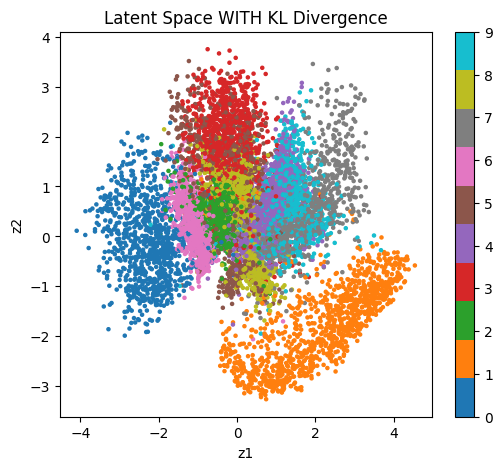

In [8]:
latent_mu, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        _, mu, _ = vae_kl(x)
        latent_mu.append(mu)
        labels.append(y)

latent_mu = torch.cat(latent_mu).numpy()
labels = torch.cat(labels).numpy()

plt.figure(figsize=(6,5))
plt.scatter(latent_mu[:,0], latent_mu[:,1], c=labels, cmap='tab10', s=5)
plt.colorbar()
plt.title("Latent Space WITH KL Divergence")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()


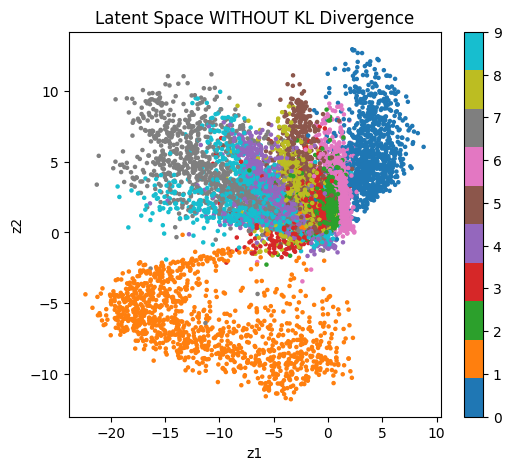

In [9]:
latent_mu, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        _, mu, _ = vae_no_kl(x)
        latent_mu.append(mu)
        labels.append(y)

latent_mu = torch.cat(latent_mu).numpy()
labels = torch.cat(labels).numpy()

plt.figure(figsize=(6,5))
plt.scatter(latent_mu[:,0], latent_mu[:,1], c=labels, cmap='tab10', s=5)
plt.colorbar()
plt.title("Latent Space WITHOUT KL Divergence")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()
